In [ ]:
import numpy as np
import numpy.random as random
import scipy as sp
from pandas import Series, DataFrame
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

import sklearn

%precision 3

'%.3f'

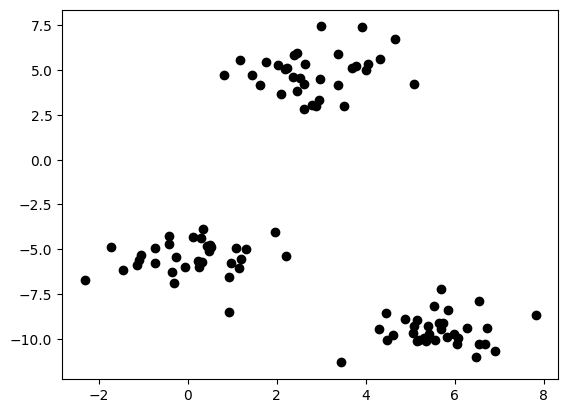

In [ ]:
# 9-2-2
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X,_ = make_blobs(random_state=10)

plt.scatter(X[:,0],X[:,1], color='black')

In [ ]:
kmeans = KMeans(init = 'random', n_clusters=3)
kmeans.fit(X)

y_pred = kmeans.predict(X)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


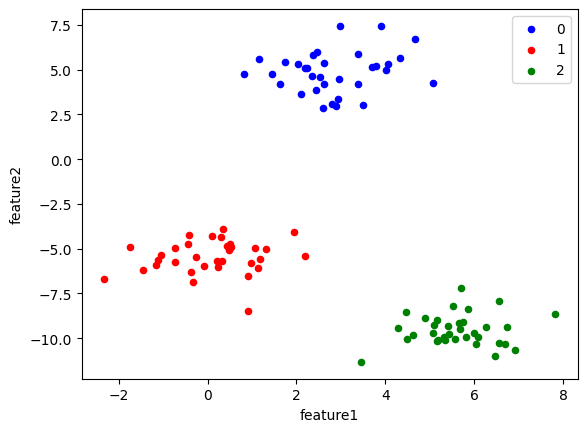

In [ ]:
merge_data = pd.concat([pd.DataFrame(X[:,0]), pd.DataFrame(X[:,1]), pd.DataFrame(y_pred)], axis=1)
merge_data.columns = ['feature1','feature2','cluster']

ax = None

colors = ['blue', 'red', 'green']

for i, data in merge_data.groupby('cluster'):
    ax = data.plot.scatter(x='feature1', y='feature2', color=colors[i], label=i, ax=ax)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Text(0, 0.5, 'Distortion')

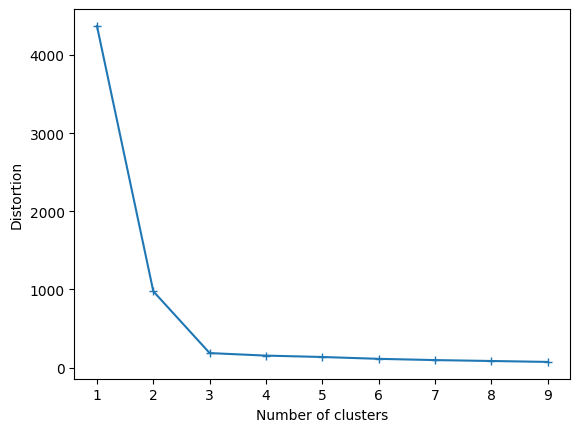

In [ ]:
# 9-2-4
dist_list = []
for i in range(1,10):
    kmeans = KMeans(n_clusters=i, init='random', random_state=0)
    kmeans.fit(X)
    dist_list.append(kmeans.inertia_)

plt.plot(range(1,10), dist_list, marker='+')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Text(0, 0.5, 'Distortion')

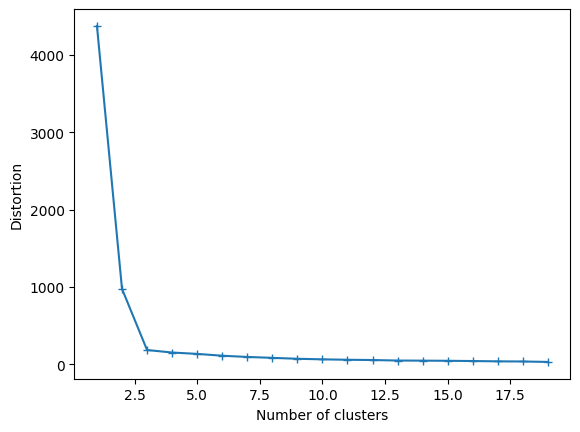

In [ ]:
dist_list = []
for i in range(1,20):
    kmeans = KMeans(n_clusters=i, init='random', random_state=0)
    kmeans.fit(X)
    dist_list.append(kmeans.inertia_)

plt.plot(range(1,20), dist_list, marker='+')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')

相関係数0.889


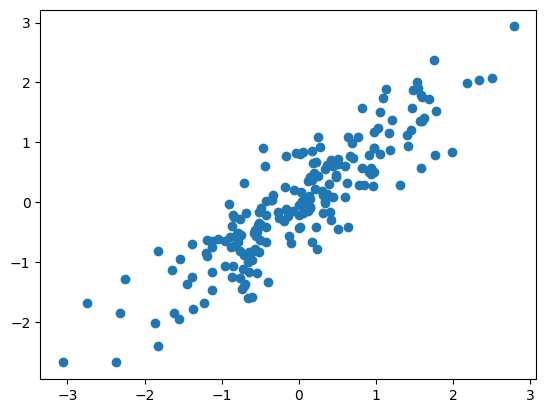

In [ ]:
# 9-3-1
from sklearn.preprocessing import StandardScaler

sample = np.random.RandomState(1)

X = np.dot(sample.rand(2,2), sample.randn(2,200)).T

sc = StandardScaler()
X_std = sc.fit_transform(X)

print('相関係数{:.3f}'.format(sp.stats.pearsonr(X_std[:, 0], X_std[:,1])[0]))
plt.scatter(X_std[:,0], X_std[:,1])

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_std)

PCA(n_components=2)

In [ ]:
print(pca.components_)

[[-0.707 -0.707]
 [-0.707  0.707]]


In [ ]:
print('各主成分の分散:{}'.format(pca.explained_variance_ratio_))

各主成分の分散:[0.945 0.055]


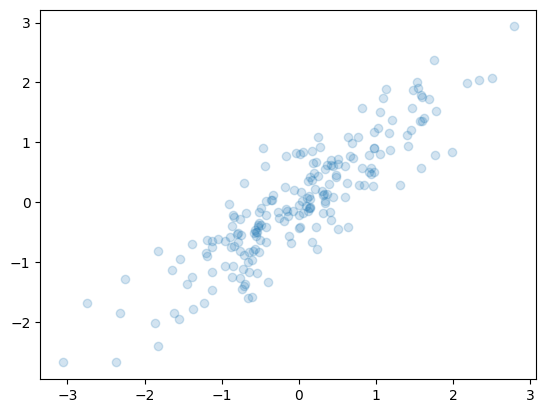

In [ ]:
arrowprops = dict(arrowstyle='->', linewidth=2, shrinkA=0, shrinkB=0)

def draw_vector(v0, v1):
    plt.gca().annotate('', v1, v0, arrowprops=arrowprops)
plt.scatter(X_std[:,0], X_std[:,1], alpha=0.2)

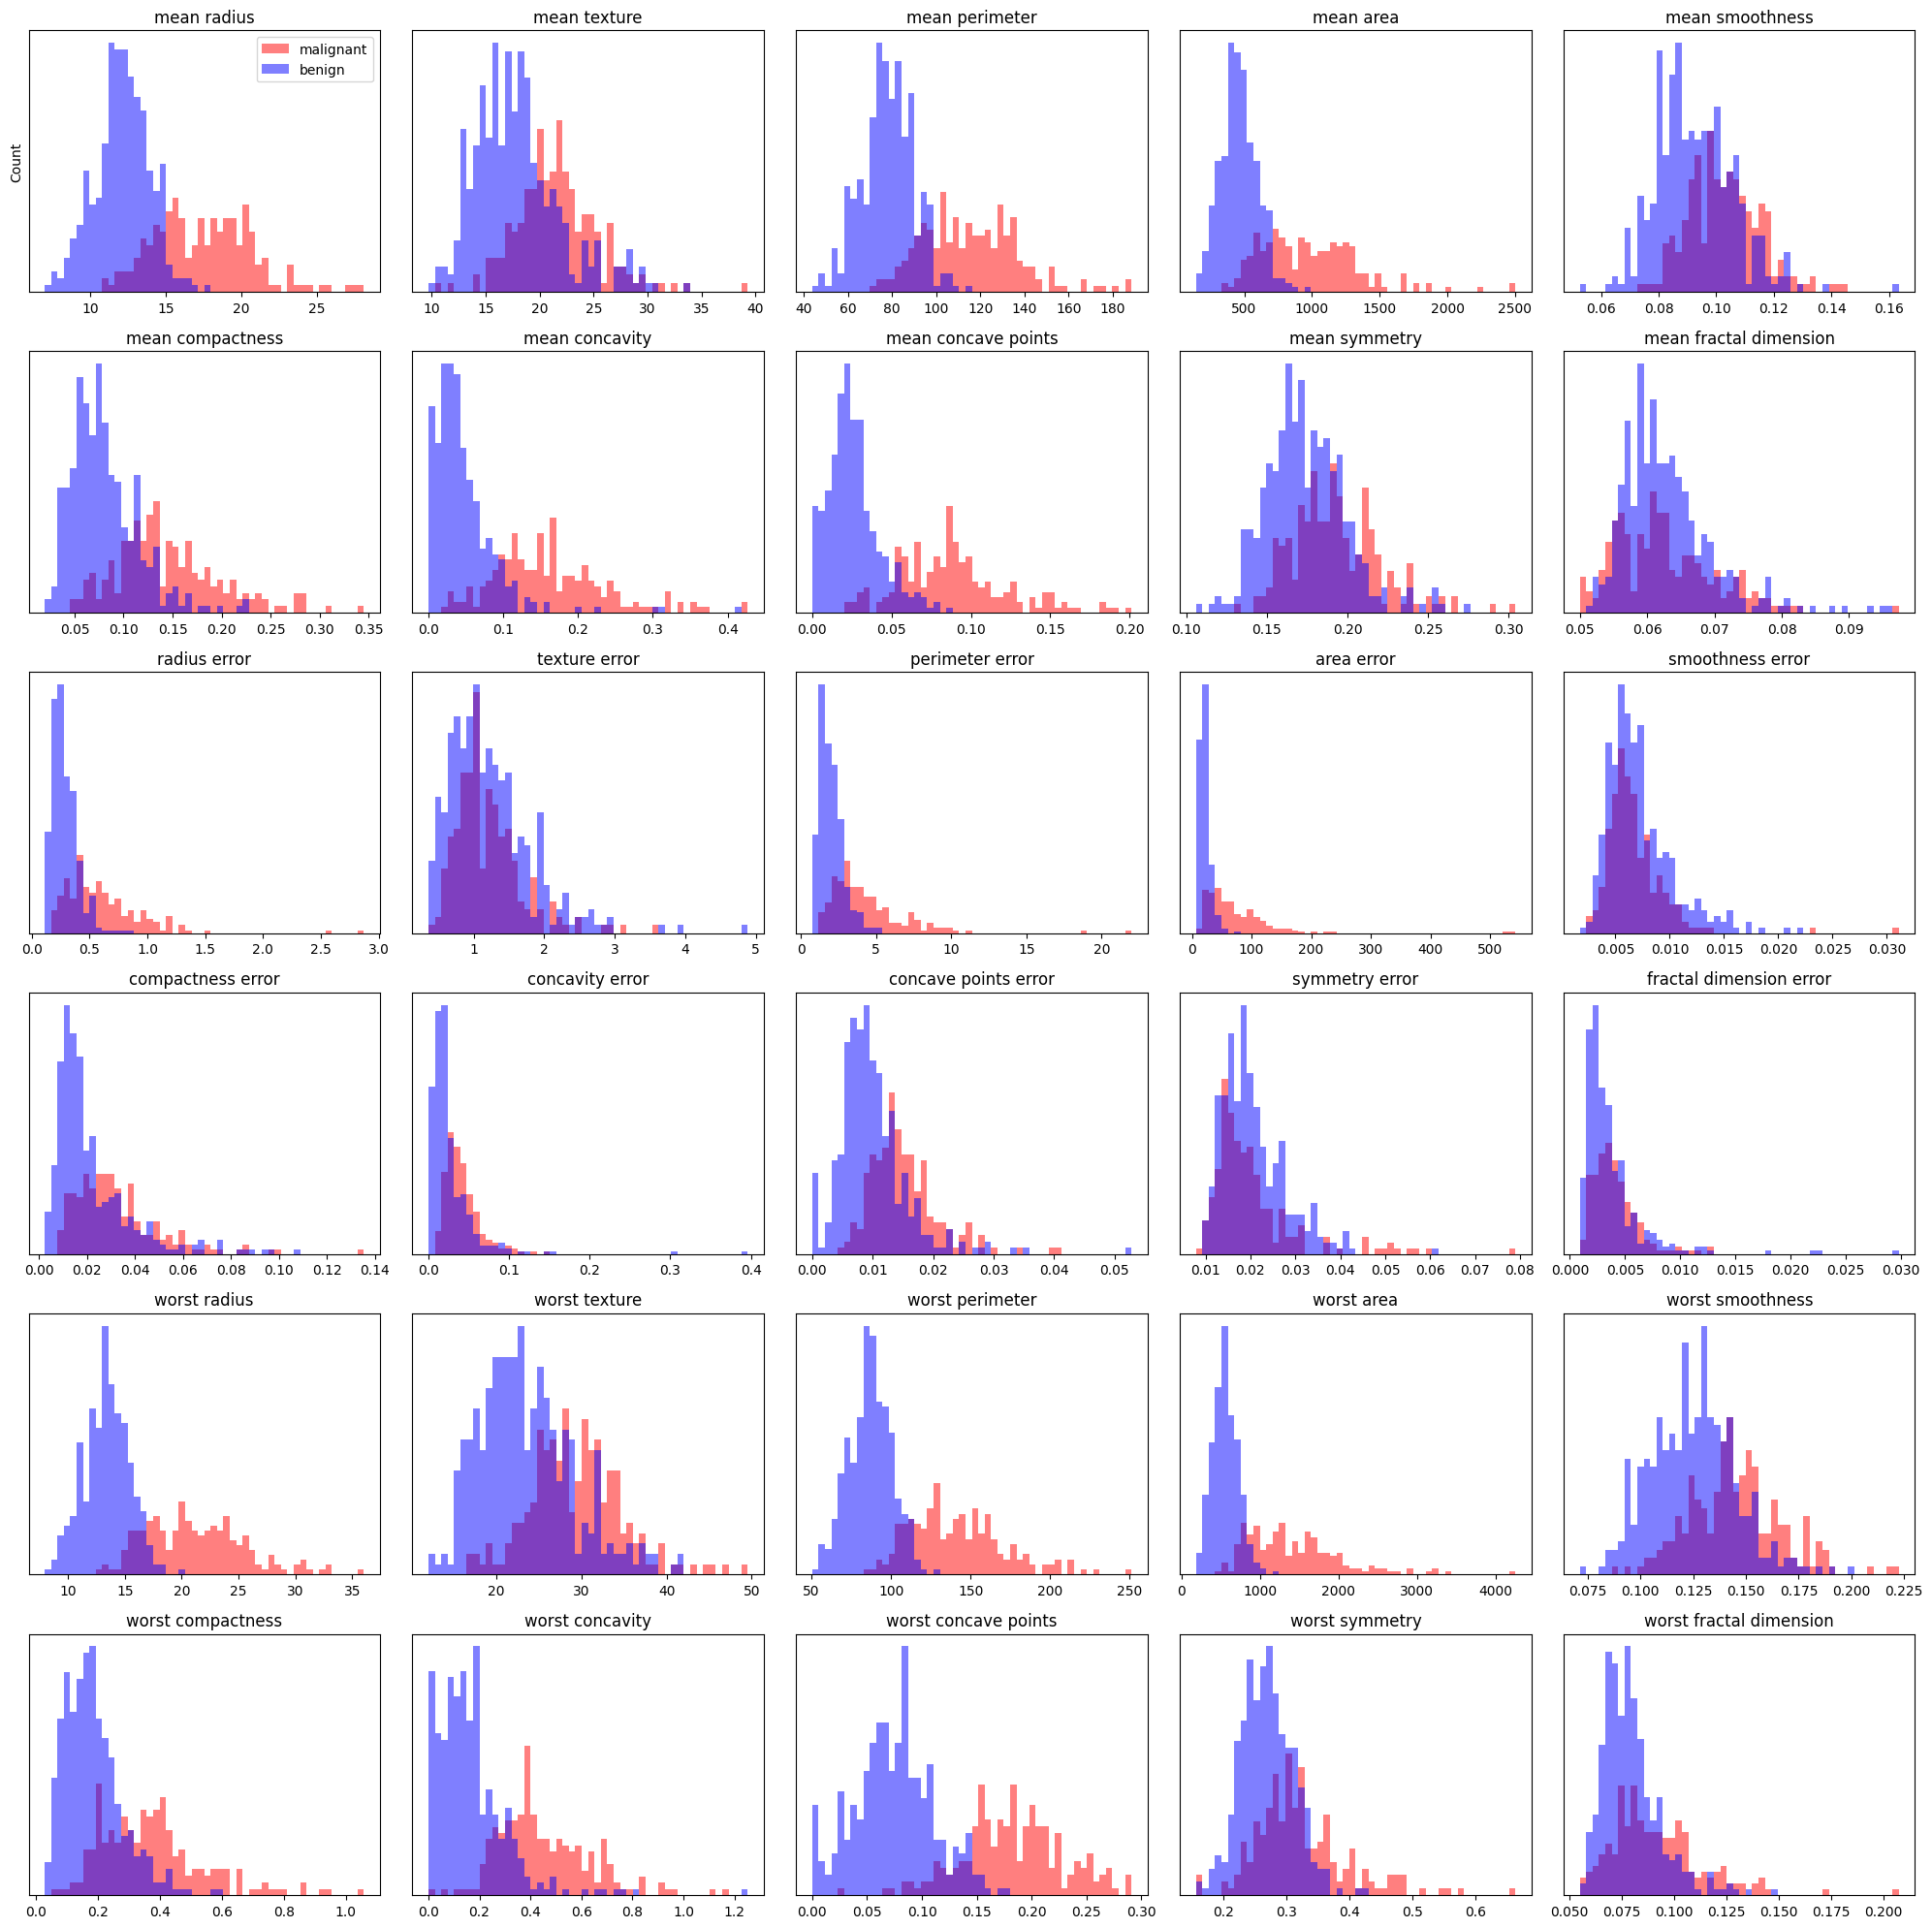

In [ ]:
# 9-3-2
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

malignant = cancer.data[cancer.target==0]
benign = cancer.data[cancer.target==1]

fig, axes = plt.subplots(6,5, figsize=(20,20))

ax = axes.ravel()

for i in range(30):
    _, bins = np.histogram(cancer.data[:,i], bins=50)
    ax[i].hist(malignant[:,i], bins=bins, color='red', alpha=0.5)
    ax[i].hist(benign[:,i], bins=bins, color='blue', alpha=0.5)
    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())

ax[0].set_ylabel('Count')
ax[0].legend(['malignant', 'benign'], loc='best')
fig.tight_layout()

In [ ]:
sc = StandardScaler()
X_std = sc.fit_transform(cancer.data)

pca = PCA(n_components=2)
pca.fit(X_std)

X_pca = pca.transform(X_std)

print('X_pca shape:{}'.format(X_pca.shape))
print('Expained variance ratio:{}'.format(pca.explained_variance_ratio_))

X_pca shape:(569, 2)
Expained variance ratio:[0.443 0.19 ]


In [ ]:
X_pca  = pd.DataFrame(X_pca, columns=['PC1','PC2'])
X_pca = pd.concat([X_pca, pd.DataFrame(cancer.target, columns=['target'])], axis=1)

pca_malignant = X_pca[X_pca.target==0]
pca_benign = X_pca[X_pca.target==1]

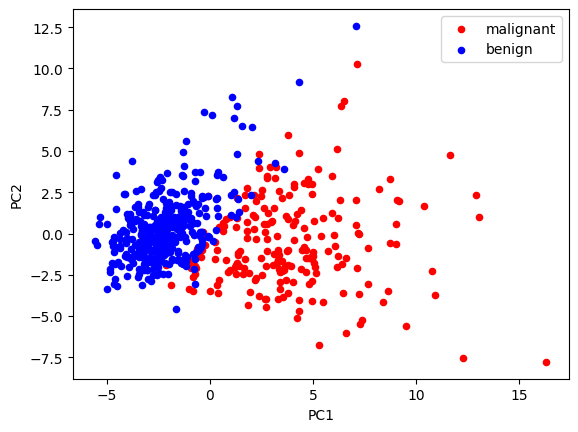

In [ ]:
ax = pca_malignant.plot.scatter(x='PC1', y='PC2', color='red', label='malignant');
pca_benign.plot.scatter(x='PC1', y='PC2', color='blue', label='benign', ax=ax);


In [ ]:
# Practice 9-2

from sklearn.datasets import load_iris

iris = load_iris()

malignant = iris.data[iris.target==0]
benign = iris.data[iris.target==1]

sc = StandardScaler()

X_std = sc.fit_transform(iris.data)

pca = PCA(n_components=2)
pca.fit(X_std)

X_pca = pca.transform(X_std)

print('主成分分析前のデータ:{}'.format(iris.data.shape))
print('主成分分析後のデータ:{}'.format(X_pca.shape))


主成分分析前のデータ次元:(150, 4)
主成分分析後のデータ:(150, 2)


In [ ]:
X_pca  = pd.DataFrame(X_pca, columns=['PC1','PC2'])
X_pca = pd.concat([X_pca, pd.DataFrame(iris.target, columns=['target'])], axis=1)

pca_malignant = X_pca[X_pca.target==0]
pca_benign = X_pca[X_pca.target==1]

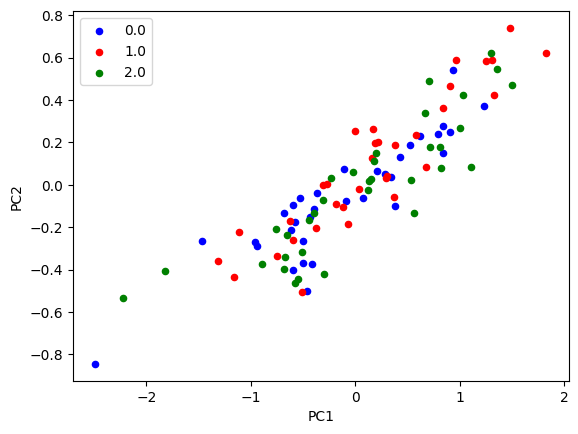

In [ ]:
merge_data = pd.concat([pd.DataFrame(X[:,0]), pd.DataFrame(X[:,1]), pd.DataFrame(y_pred)], axis=1)
merge_data.columns = ['PC1','PC2','cluster']

ax = None

colors = ['blue', 'red', 'green']

# Use enumerate to get both the index and the data
for idx, (i, data) in enumerate(merge_data.groupby('cluster')):
    ax = data.plot.scatter(x='PC1', y='PC2', color=colors[idx], label=i, ax=ax) # Use idx to index colors

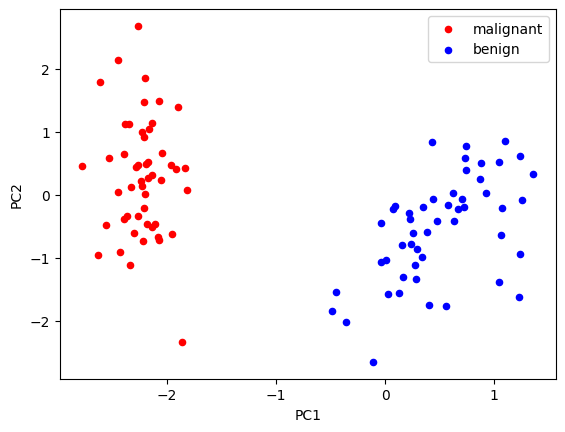

In [ ]:
ax = pca_malignant.plot.scatter(x='PC1', y='PC2', color='red', label='malignant');
pca_benign.plot.scatter(x='PC1', y='PC2', color='blue', label='benign', ax=ax);

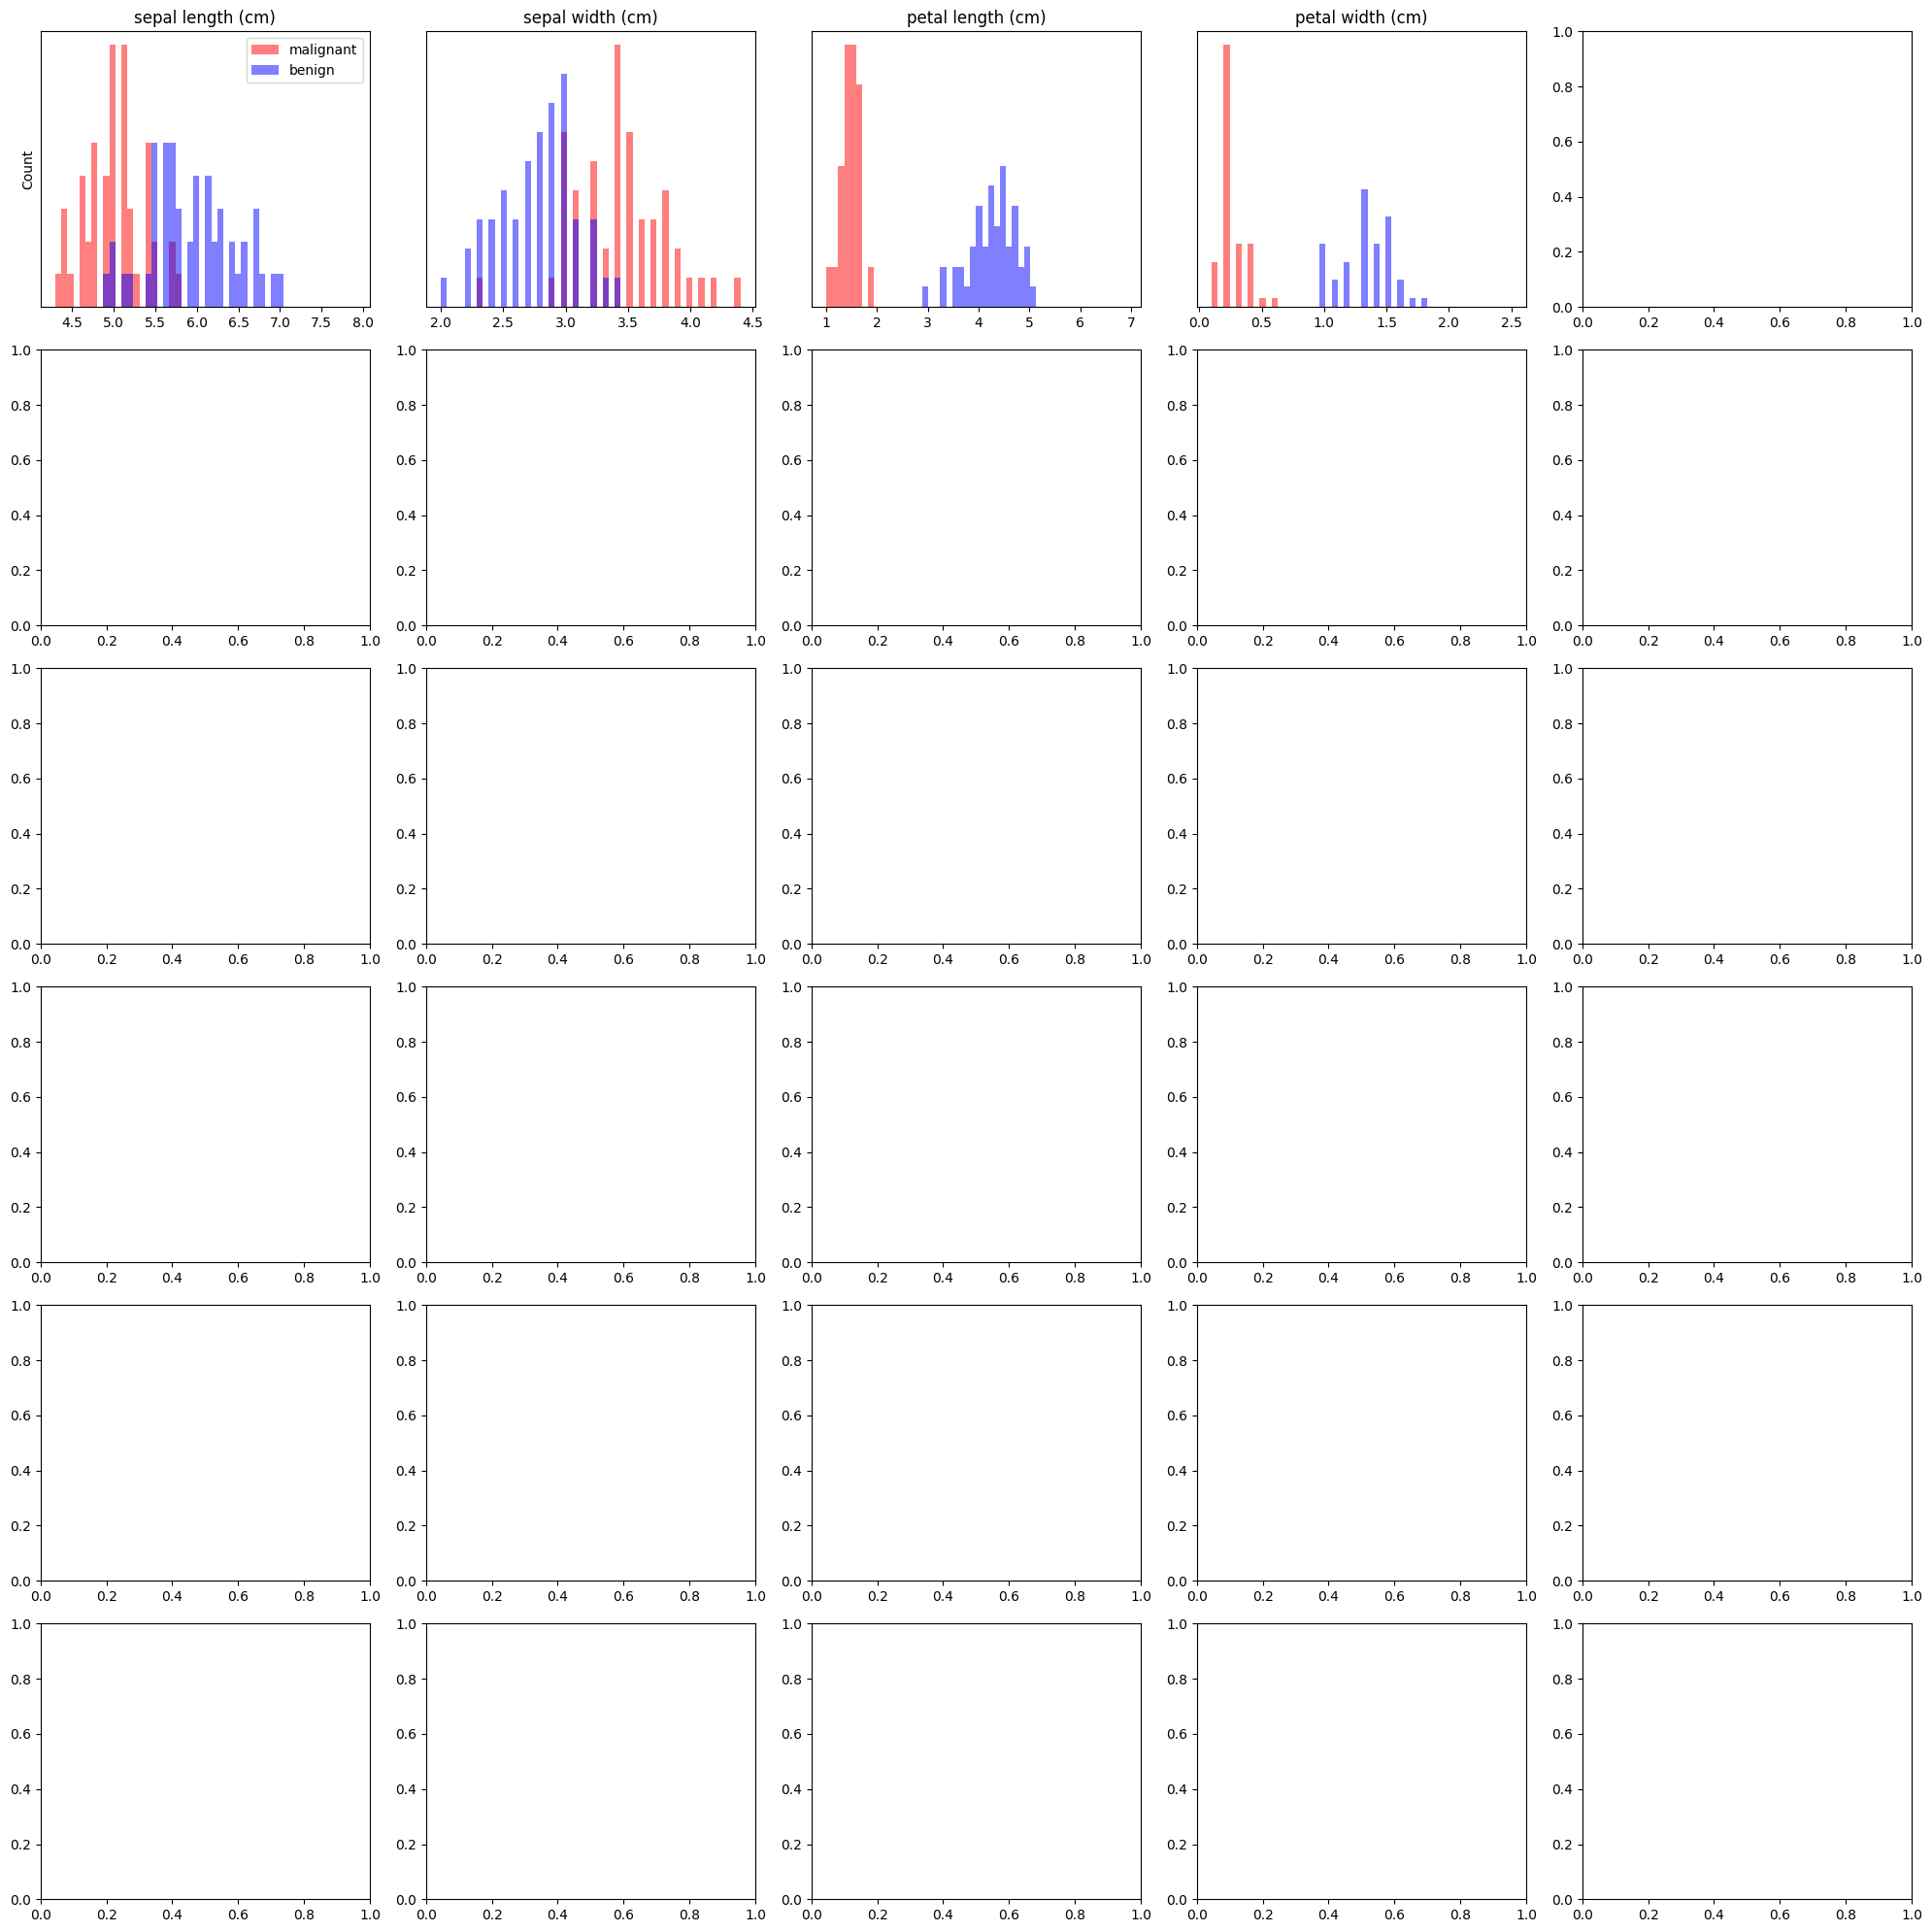

In [ ]:
fig, axes = plt.subplots(6,5, figsize=(20,20))

ax = axes.ravel()

for i in range(4):
    _, bins = np.histogram(iris.data[:,i], bins=50)
    ax[i].hist(malignant[:,i], bins=bins, color='red', alpha=.5)
    ax[i].hist(benign[:,i], bins=bins, color='blue', alpha=.5)
    ax[i].set_title(iris.feature_names[i])
    ax[i].set_yticks(())

ax[0].set_ylabel('Count')
ax[0].legend(['malignant', 'benign'], loc='best')
fig.tight_layout()